In [38]:
import spotipy
from spotipy.oauth2 import SpotifyOAuth
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import matplotlib.pyplot as plt
import math
import seaborn as sns
import re

# Initialize the Spotify API client
sp = spotipy.Spotify(auth_manager=SpotifyOAuth(client_id="f6f6de34e09741d28b1766703ec2560a",
                                               client_secret="19cd0d5906204557934a27406a24e4ca",
                                               redirect_uri="http://localhost:8888/callback",
                                               scope="user-library-read playlist-modify-public playlist-read-private",
                                               requests_timeout=30))

In [87]:
comp = pd.read_csv(r'./data/pennstahtspring2025/competitors.csv')
roun = pd.read_csv(r'./data/pennstahtspring2025/rounds.csv')
subm = pd.read_csv(r'./data/pennstahtspring2025/submissions.csv')
vote = pd.read_csv(r'./data/pennstahtspring2025/votes.csv')

subb = subm[['Spotify URI','Submitter ID','Round ID']].rename(columns={'Submitter ID':'Voter ID'})
subb['Points Assigned'] = 5
vote = pd.concat([subb,vote])

vote = vote.merge(comp,left_on='Voter ID',right_on='ID').drop(columns='ID')
roun1 = roun[['ID','Name']].rename(columns={'ID':'Round ID','Name': 'Round'})

vote = vote.merge(roun1,on='Round ID')

votesum = vote.groupby(['Round ID','Name'])['Points Assigned'].agg('sum').reset_index()
votesum = votesum[votesum['Points Assigned']>100].drop(columns='Points Assigned')

df_filtered = vote.merge(votesum, on=['Round ID', 'Name'], how='left', indicator=True)
df_filtered = df_filtered[df_filtered['Name']!='Anna Render']
vote = df_filtered[df_filtered['_merge'] == 'left_only'].drop(columns=['_merge'])

# Merge Submitter ID from subm into vote
vote = vote.merge(subm[['Spotify URI', 'Submitter ID']], on='Spotify URI', how='left')

# Merge Submitter Name (Name column) from comp into vote
vote = vote.merge(comp[['ID', 'Name']].rename(columns={'ID': 'Submitter ID', 'Name': 'Submitter Name'}), on='Submitter ID', how='left')

In [91]:
vote.groupby(['Submitter Name'])['Comment'].agg('count').sort_values()

Submitter Name
Anna Render         7
Nathalie Kirby     44
Cam Mallett        45
Emily Lundstrom    49
Patrick Thomas     50
Jiggy Gosalia      52
Nick Kitchen       52
FedEx Pope         53
Sean Thomas        59
Maggi              59
joilyrancher       59
Raymond Tana       60
Erika Frees        64
Name: Comment, dtype: int64

In [94]:
#filtered_vote = vote[vote['Round'] != 'Survival 🔪 Week (TV show theme songs)']
most_negative_points = vote[vote['Points Assigned'] == -1].groupby('Submitter Name').size().sort_values(ascending=False)
print(most_negative_points)

Submitter Name
Maggi              17
FedEx Pope         16
joilyrancher       15
Sean Thomas        14
Nathalie Kirby     12
Cam Mallett        11
Nick Kitchen       10
Emily Lundstrom    10
Raymond Tana        9
Patrick Thomas      8
Jiggy Gosalia       7
Anna Render         5
Erika Frees         3
dtype: int64


C:\Users\ajwin\AppData\Local\Temp\ipykernel_73788\1270962771.py:34: UserWarning: Glyph 127801 (\N{ROSE}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_73788\1270962771.py:34: UserWarning: Glyph 129655 (\U0001fa77) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_73788\1270962771.py:34: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_73788\1270962771.py:34: UserWarning: Glyph 127997 (\N{EMOJI MODIFIER FITZPATRICK TYPE-4}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap {}.png'.format(safe_filename))
C:\Users\ajwin\AppData\Local\Temp\ipykernel_73788\1270962771.py:34: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  plt.savefig('heatmap {}.png'.fo

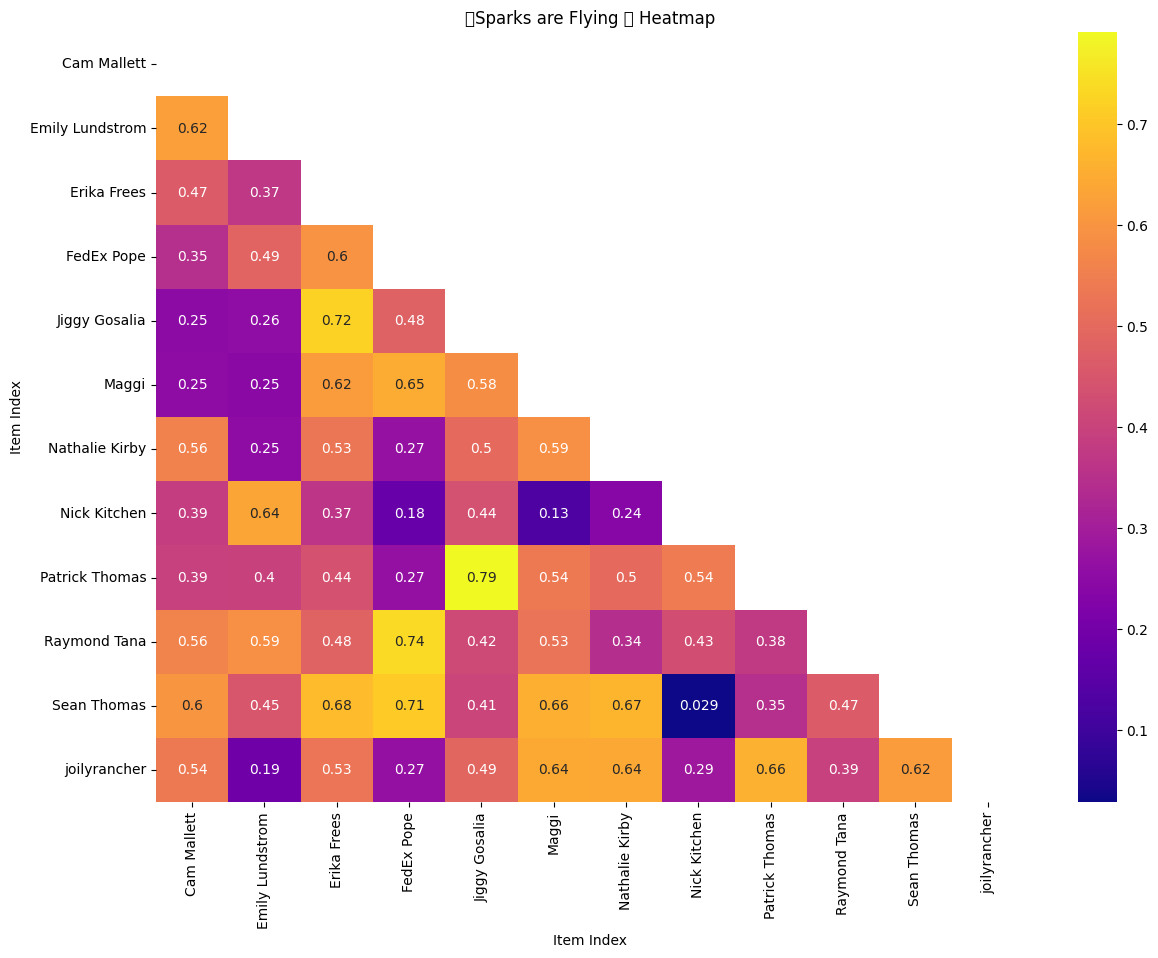

c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127997 (\N{EMOJI MODIFIER FITZPATRICK TYPE-4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


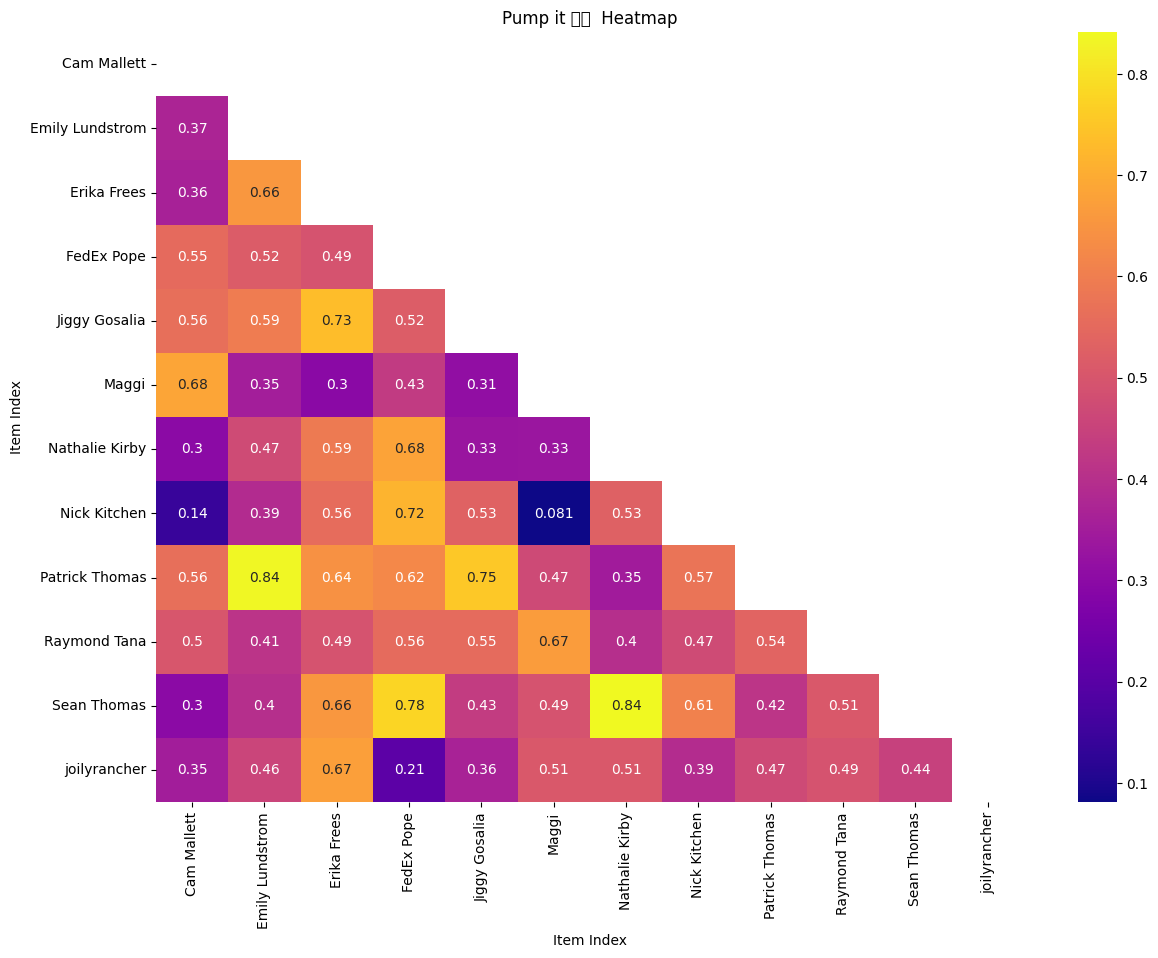

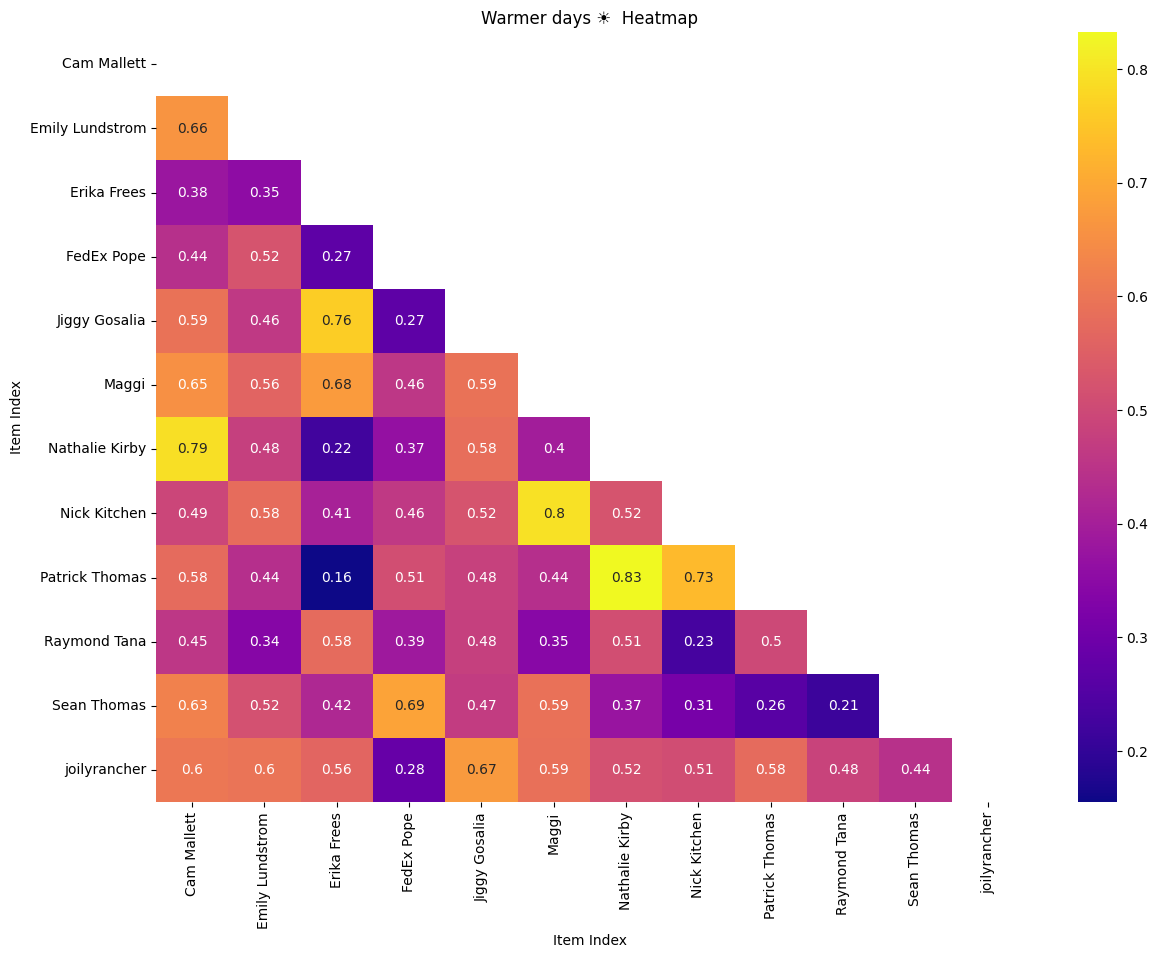

c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127758 (\N{EARTH GLOBE AMERICAS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


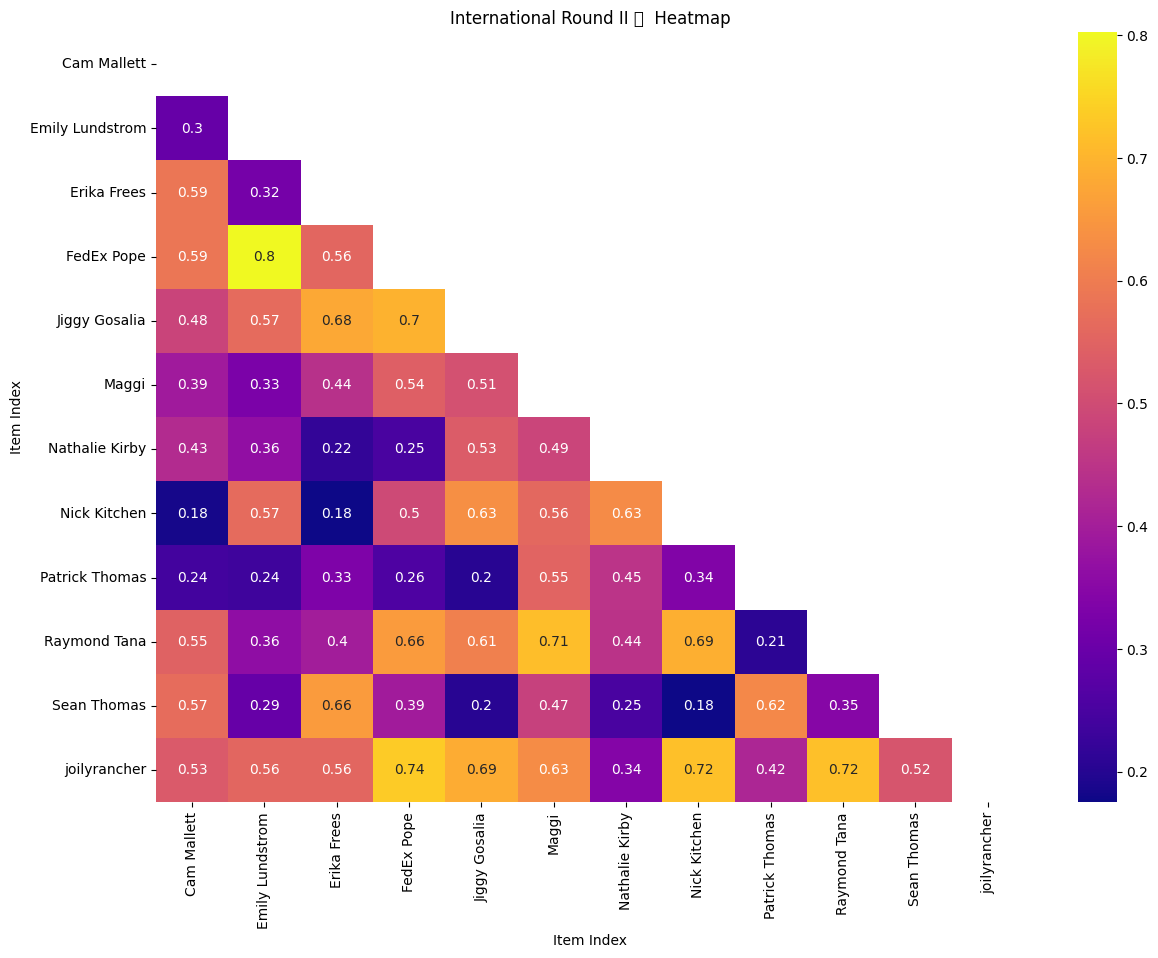

c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127786 (\N{CLOUD WITH TORNADO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


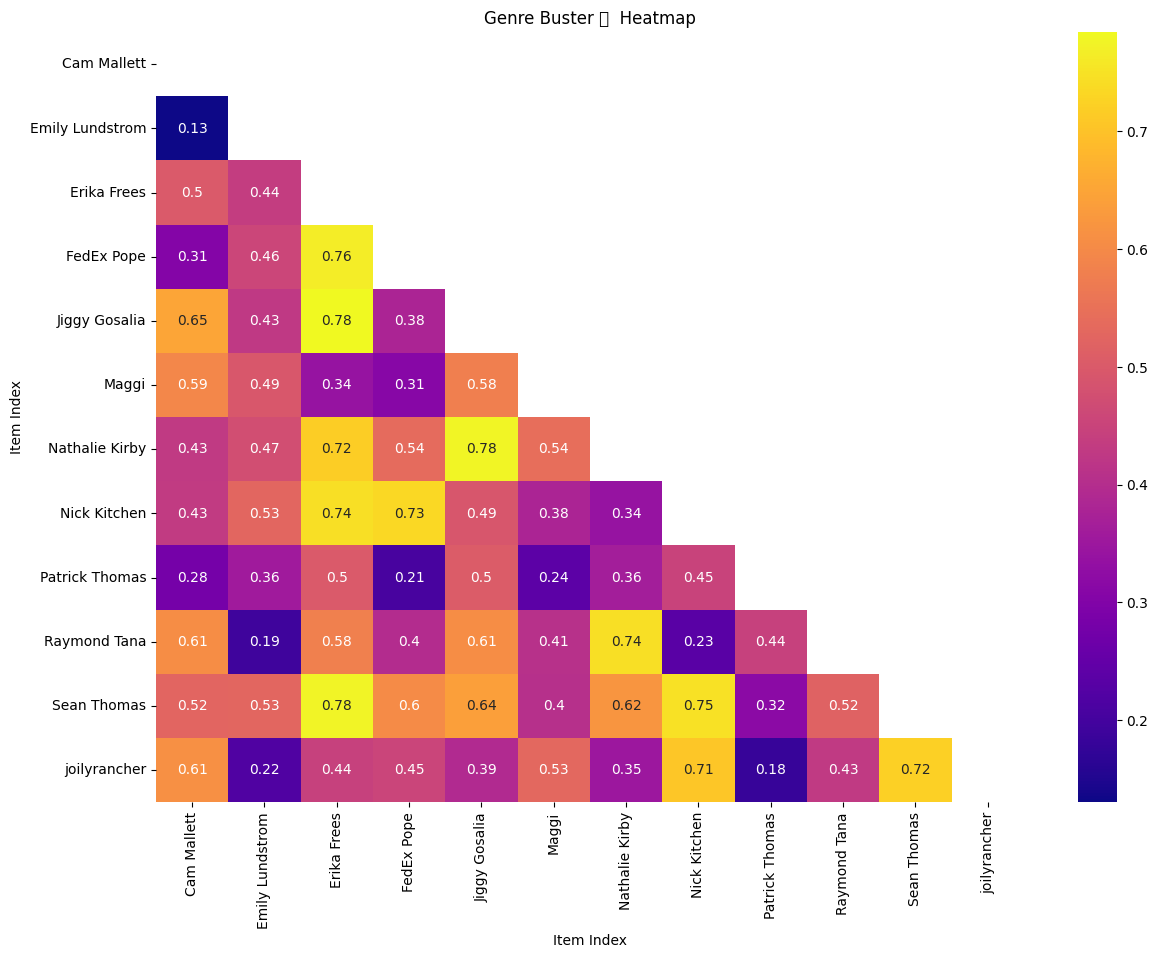

c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129728 (\N{ANATOMICAL HEART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


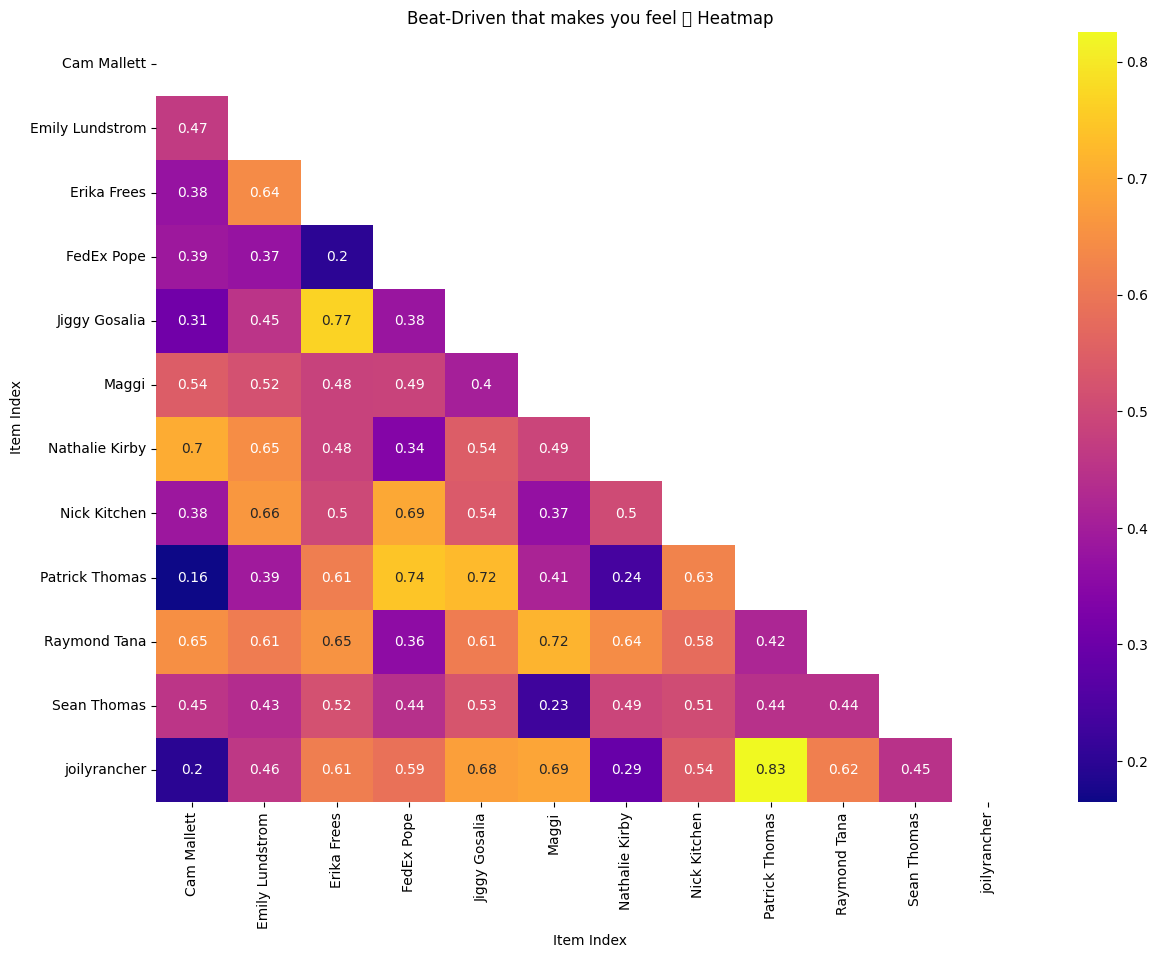

c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 129767 (\U0001fae7) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


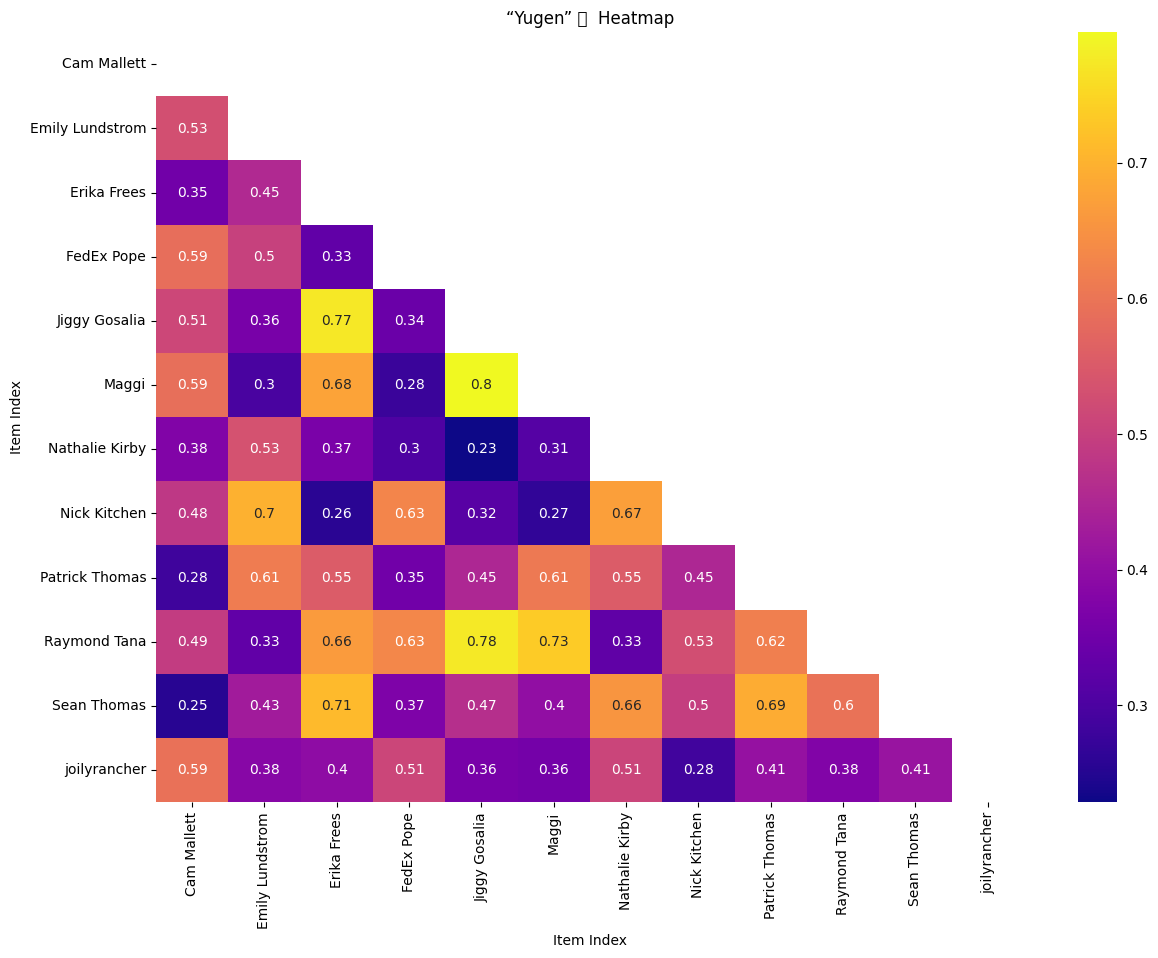

c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127811 (\N{LEAF FLUTTERING IN WIND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


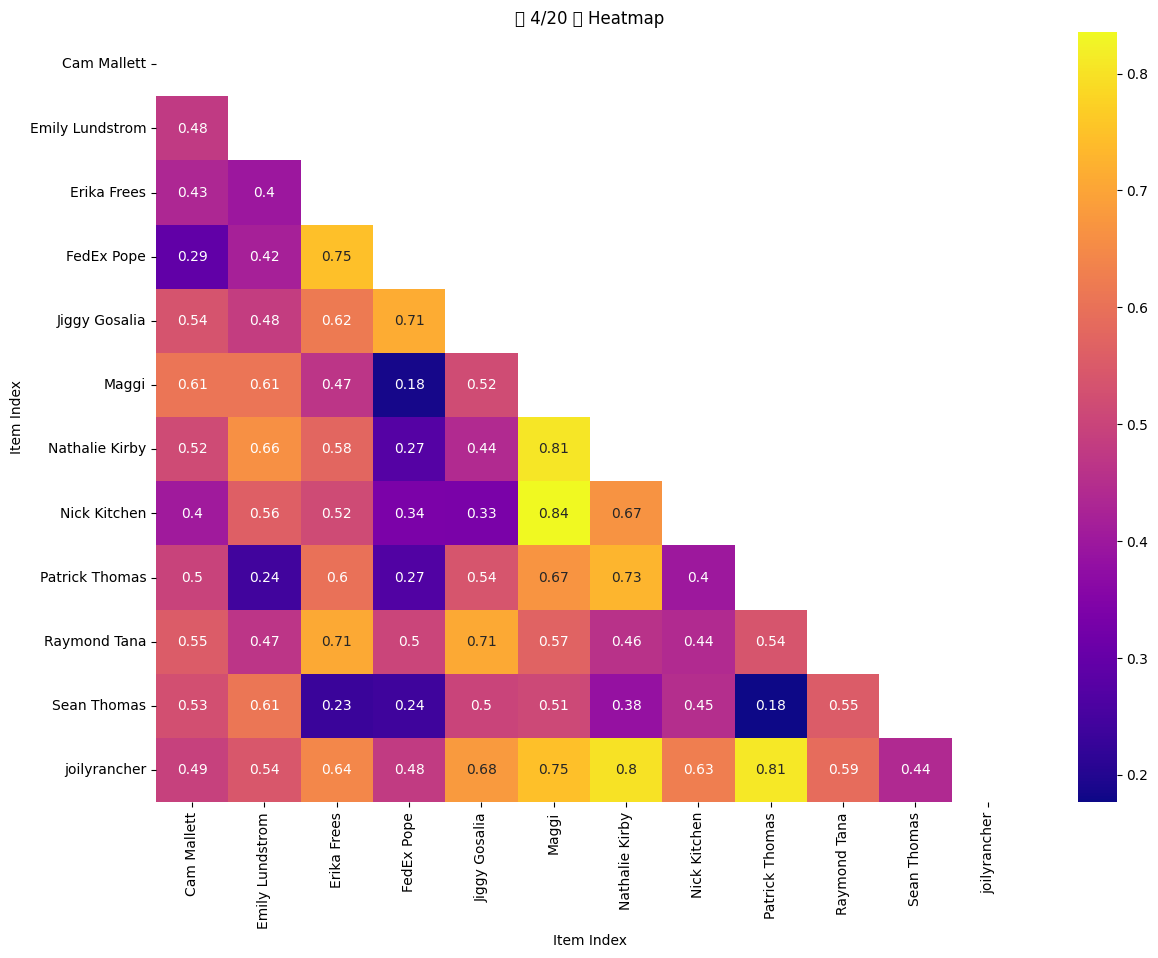

c:\Users\ajwin\Projects\SpotifyPlayground\.venv\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 127752 (\N{RAINBOW}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


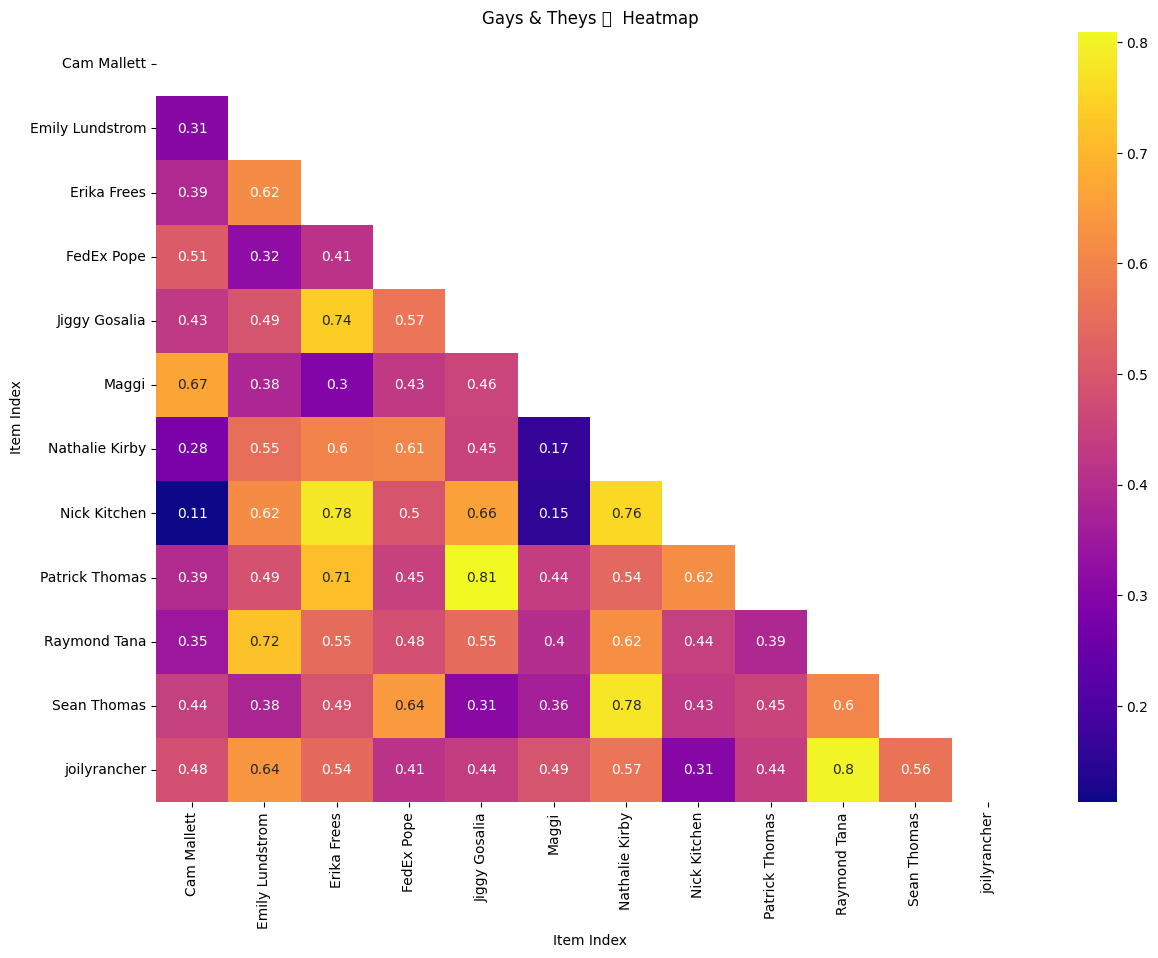

In [49]:
# Create a pivot table of Points Assigned by Voter ID and Song

for i in vote['Round'].unique():
    filename = i
    # Remove problematic characters
    safe_filename = re.sub(r'[\\/:"*?<>|]', '_', filename)
    safe_filename = safe_filename.encode('ascii', 'ignore').decode()
    
    voter = vote[vote['Round'] == i]

    pivot = voter.pivot_table(
        index='Name', columns='Spotify URI', values='Points Assigned', fill_value=0
    )

    # Compute the similarity matrix (cosine similarity)
    similarity_matrix = cosine_similarity(pivot)
    #similarity_matrix = np.dot(pivot, pivot.T)

    # Convert the matrix to a DataFrame for easier manipulation
    similarity_df = pd.DataFrame(
        similarity_matrix, index=pivot.index, columns=pivot.index
    )
    mask = np.triu(np.ones_like(similarity_df, dtype=bool))

    similarity_df.to_csv('similarity_df.csv')

    plt.figure(figsize=(14, 10))
    sns.heatmap(similarity_df,mask=mask, annot=True, cmap="plasma", cbar=True)

    # Add labels
    plt.title("{} Heatmap".format(i))
    plt.xlabel("Item Index")
    plt.ylabel("Item Index")
    plt.savefig('heatmap {}.png'.format(safe_filename))
    # Show plot
    #plt.show()



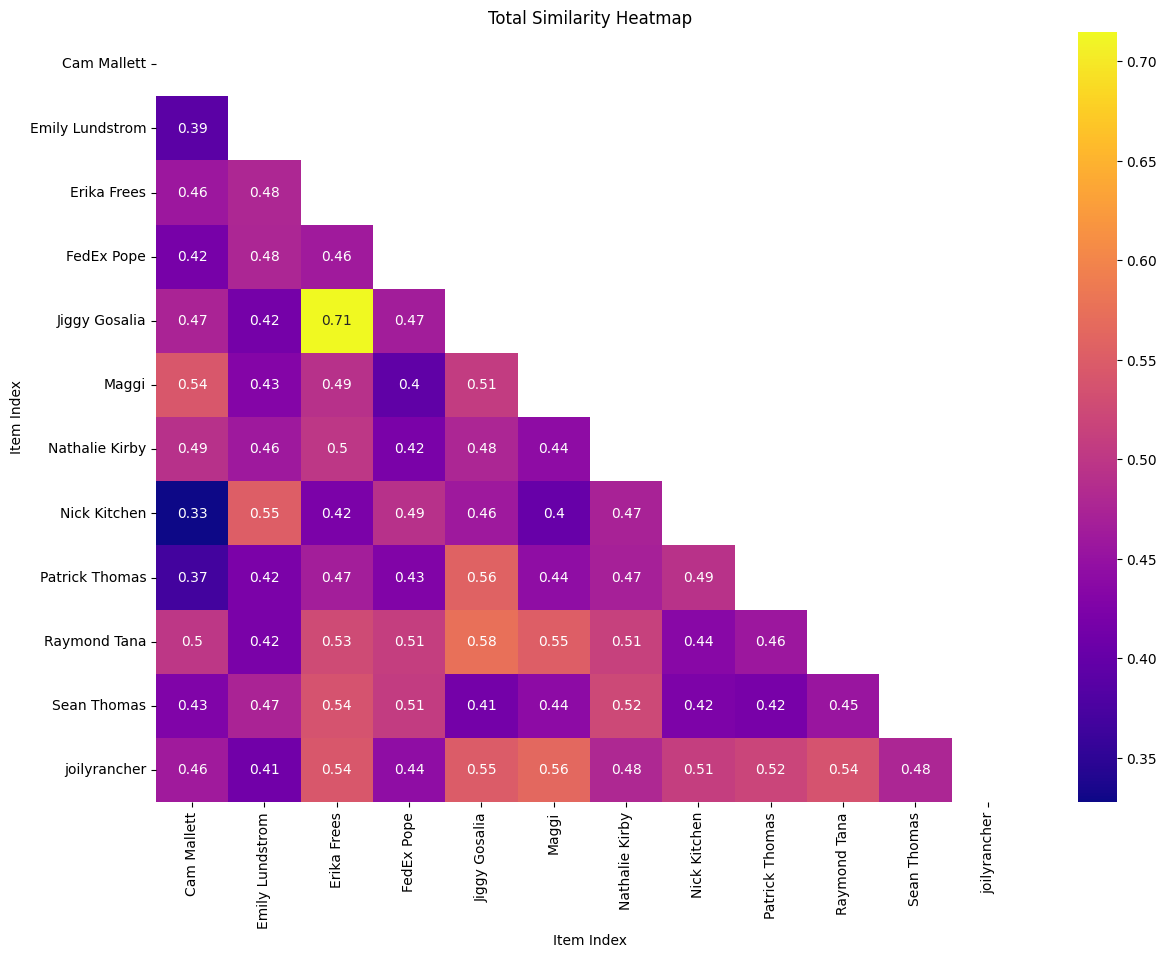

In [95]:

pivot = vote.pivot_table(
    index='Name', columns='Spotify URI', values='Points Assigned', fill_value=0
)

# Compute the similarity matrix (cosine similarity)
similarity_matrix = cosine_similarity(pivot)
#similarity_matrix = np.dot(pivot, pivot.T)

# Convert the matrix to a DataFrame for easier manipulation
similarity_df = pd.DataFrame(
    similarity_matrix, index=pivot.index, columns=pivot.index
)
mask = np.triu(np.ones_like(similarity_df, dtype=bool))

similarity_df.to_csv('similarity_df.csv')

plt.figure(figsize=(14, 10))
sns.heatmap(similarity_df,mask=mask, annot=True, cmap="plasma", cbar=True)

# Add labels
plt.title("{} Heatmap".format("Total Similarity"))
plt.xlabel("Item Index")
plt.ylabel("Item Index")
plt.savefig('heatmap {}.png'.format('Total Similarity'))
# Show plot
#plt.show()

In [55]:

# # Create a graph using NetworkX
# G = nx.Graph()

# # Add nodes (Voter IDs)
# for voter in similarity_df.index:
#     G.add_node(voter)

# # Add weighted edges based on similarity
# for i, voter1 in enumerate(similarity_df.index):
#     for j, voter2 in enumerate(similarity_df.columns):
#         if i != j:  # Exclude self-similarity
#             weight = similarity_df.iloc[i, j]
#             if weight > 0:  # Add an edge only if there’s some similarity
#                 G.add_edge(voter1, voter2, weight=weight**2)

# # Use a force-directed layout (spring layout) where edge weights determine proximity
# pos = nx.spring_layout(G, weight='weight', seed=42)

# # Visualize the graph
# plt.figure(figsize=(12, 12))
# nx.draw(
#     G, pos, with_labels=True, node_color='lightblue', edge_color='gray',
#     node_size=3000, font_size=10, font_weight='bold'
# )

# # Add edge labels to show weights
# edge_labels = nx.get_edge_attributes(G, 'weight')
# edge_labels = {key: f"{value:.2f}" for key, value in edge_labels.items()}
# nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

# plt.title("Voting Similarity Network (Proximity Based on Strength of Similarity)")
# plt.savefig('../output/network graph fall songs.png')
# #plt.show()

In [24]:
value_counts = vote['Points Assigned'].value_counts().sort_index()


In [52]:
similarity_df.mean().sort_values()

Name
Cam Mallett        0.500480
Emily Lundstrom    0.501929
FedEx Pope         0.511381
Patrick Thomas     0.513030
Nick Kitchen       0.516711
Sean Thomas        0.524740
Maggi              0.527223
Nathalie Kirby     0.533230
joilyrancher       0.547091
Raymond Tana       0.549934
Erika Frees        0.559530
Jiggy Gosalia      0.564875
dtype: float64